# Ovarian cancer data analysis
Train steamboat model on HGSC data.

In [3]:
import os
import scanpy as sc
import numpy as np
import scipy as sp
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl

In [4]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

## Load data

In [5]:
adata = sc.read_h5ad("G:/data/slidetags/HumanTonsil.h5ad")

## Attention map interpretation: Cell-cell interaction

In [6]:
from cellphonedb.src.core.methods import cpdb_analysis_method
import pickle as pkl
from tqdm.notebook import tqdm

In [7]:
! mkdir cellphonedb-res

A subdirectory or file cellphonedb-res already exists.


In [ ]:

abundant_cell_types = (adata.obs['cluster'].value_counts() >= 10).where(lambda x: x).dropna().index.tolist()
adata = adata[adata.obs['cluster'].isin(abundant_cell_types)]

df_meta = pd.DataFrame(data={'Cell':list(adata.obs.index),
                                'cluster':[ i for i in adata.obs['cluster']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv('cellphonedb-res/tonsil_meta.tsv', sep = '\t')
df_meta

cpdb_results = cpdb_analysis_method.call(
    cpdb_file_path = '../experiments/cellphonedb-res/db/v5.0.0/cellphonedb.zip',           # mandatory: CellphoneDB database zip file.
    meta_file_path = 'cellphonedb-res/tonsil_meta.tsv',           # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = adata,       # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',               # defines the gene annotation in counts matrix.
    microenvs_file_path = None, # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                 # optional: whether to score interactions or not. 
    output_path = 'cellphonedb-res/',                    # Path to save results    microenvs_file_path = None,
    separator = '|',                           # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    threads = 5,                               # number of threads to use in the analysis.
    threshold = 0.1,                           # defines the min % of cells expressing a gene for this to be employed in the analysis.
    result_precision = 3,                      # Sets the rounding for the mean values in significan_means.
    debug = False,                             # Saves all intermediate tables emplyed during the analysis in pkl format.
    output_suffix = None                       # Replaces the timestamp in the output files by a user defined string in the  (default: None)
)

with open(f'cellphonedb-res/tonsil.pkl', 'wb') as f:
    pkl.dump(cpdb_results, f)
    

[ ][CORE][30/11/25-00:14:33][INFO] [Non Statistical Method] Threshold:0.1 Precision:3


Reading user files...
The following user files were loaded successfully:
counts from AnnData object
cellphonedb-res/tonsil_meta.tsv
[ ][CORE][30/11/25-00:14:36][INFO] Running Basic Analysis
[ ][CORE][30/11/25-00:14:36][INFO] Building results
[ ][CORE][30/11/25-00:14:37][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 13/13 [00:00<00:00, 117.12it/s]

[ ][CORE][30/11/25-00:14:37][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 13/13 [00:00<00:00, 342.12it/s]


[ ][CORE][30/11/25-00:14:37][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 169/169 [00:39<00:00,  4.32it/s]


Saved means_result to cellphonedb-res/simple_analysis_means_result_11_30_2025_001517.txt
Saved deconvoluted to cellphonedb-res/simple_analysis_deconvoluted_11_30_2025_001517.txt
Saved deconvoluted_percents to cellphonedb-res/simple_analysis_deconvoluted_percents_11_30_2025_001517.txt
Saved interaction_scores to cellphonedb-res/simple_analysis_interaction_scores_11_30_2025_001517.txt


In [10]:
def unmelt(df):
    celltypes = {}
    for i in df.index:
        a, b = i.split('|')
        celltypes[a] = None
        celltypes[b] = None
    
    celltypes = list(celltypes.keys())
    df2 = pd.DataFrame(index=celltypes, columns=celltypes)
    for i in df2.index:
        for j in df2.columns:
            df2.loc[i, j] = cpdb_summary[i + '|' + j]
    return df2



In [11]:
ks = [adata.obs['samples'].astype(str).unique().item() for adata in adatas]

In [14]:
def melt_helper(x):
    x_melt = x.melt(ignore_index=False)
    x_melt['variable'] = x_melt.index + '_' + x_melt['variable']
    return x_melt

cellchat_corr_dict = {}
cellchat_melt_dict = {}

cellchat_dict = {}

for i, k in enumerate(ks):
    cellchat_res_path = f"../data/Ex1_hgsc/cellchat/{k}.csv"
    cellphonedb_res_path = f"cellphonedb-res/hgsc_{i}"
    if os.path.isfile(cellchat_res_path):
        # print(cellchat_res_path)
        cellchat = pd.read_csv(cellchat_res_path, index_col=0)
        if (cellchat == 0).all().all():
            print(cellchat_res_path, 'all zero. Ignore.')
            continue
            
        with open(cellphonedb_res_path, 'rb') as f:
            cpdb_results = pkl.load(f)
            
        cpdb_summary = cpdb_results['means_result'].loc[:, cpdb_results['means_result'].columns.str.contains('\|')].sum(axis=0)
        cpdb_unmelt = unmelt(cpdb_summary)
        cpdb_melt = melt_helper(cpdb_unmelt + cpdb_unmelt.T)
        cpdb_melt.columns = ['variable', 'value_cpdb']
            
        nichenet_unmelt = pd.read_csv(f"nichenet-res/nichenet_{k}.csv", index_col=0)
        nichenet_melt = melt_helper(nichenet_unmelt + nichenet_unmelt.T)
        nichenet_melt.columns = ['variable', 'value_nichenet']
            
        cellchat_dict[k] = cellchat
        cellchat_melt = melt_helper(cellchat + cellchat.T)
        cellchat_melt.columns = ['variable', 'value_cellchat']
        
        
        all_melt = pd.merge(cellchat_melt, cpdb_melt, on='variable', suffixes=['_cellchat', '_cpdb'])
        all_melt = pd.merge(all_melt, nichenet_melt, on='variable', suffixes=['**', '_nichenet'])
        
        corr_res = sp.stats.spearmanr(all_melt['value_cellchat'], all_melt['value_cpdb'])
        # cellchat_melt_dict[k] = all_melt
        cellchat_corr_dict[k] = [corr_res.statistic, corr_res.pvalue]
        corr_res = sp.stats.spearmanr(all_melt['value_cellchat'], all_melt['value_nichenet'])
        # cellchat_melt_dict[k] = all_melt
        cellchat_corr_dict[k].extend([corr_res.statistic, corr_res.pvalue])
        
    else:
        print(cellchat_res_path, 'not found!')

cellchat_corr_df = pd.DataFrame(cellchat_corr_dict, index=['cpdb_r', 'cpdb_p', 'nichenet_r', 'nichenet_p'])

cellchat_corr_df = cellchat_corr_df.T
cellchat_corr_df

../data/Ex1_hgsc/cellchat/SMI_T11_F011.csv all zero. Ignore.


,cpdb_r,cpdb_p,nichenet_r,nichenet_p
SMI_T10_F001,0.458672,4.899916e-03,0.430561,8.759339e-03
SMI_T10_F002,0.016216,9.386754e-01,0.040154,8.488626e-01
SMI_T10_F006,0.788266,1.145653e-08,0.448356,6.098016e-03
SMI_T10_F014,0.387645,5.554029e-02,-0.136118,5.164836e-01
SMI_T11_F001,0.699601,2.056366e-06,0.606399,8.849319e-05
SMI_T11_F002,0.602579,1.007023e-04,0.049387,7.748462e-01
SMI_T11_F004,0.562089,3.602446e-04,0.258801,1.274829e-01
SMI_T11_F008,0.607995,8.380030e-05,-0.018182,9.161779e-01
SMI_T11_F009,0.710006,1.236325e-06,0.661534,1.118120e-05
SMI_T11_F020,0.223166,2.835852e-01,0.221622,2.870172e-01


In [15]:
orig_df = pd.read_csv("../data/Ex1_hgsc/res.csv", index_col=0)
cellchat_corr_df = orig_df.merge(cellchat_corr_df, left_index=True, right_index=True)

WilcoxonResult(statistic=24.0, pvalue=2.2709369659423828e-05)


0.8461538461538461

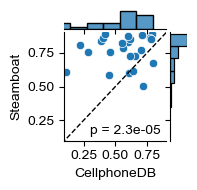

In [16]:
# fig, ax = plt.subplots(figsize=(2, 2))
# cellchat_corr_df.plot(kind='scatter', x='normneigh_r', y='steamboat_r', ax=ax)
g = sns.jointplot(
    data=cellchat_corr_df,
    x="cpdb_r", y="steamboat_r",
    kind="scatter",
    height=2,
    xlim=[0.1, .9],
    ylim=[0.1, .9]
)

ax = g.ax_joint

ax.set_xlabel('CellphoneDB')
ax.set_ylabel('Steamboat')
ax.plot([.0, 1.], [.0, 1.], ls='--', lw=1., c='k')

test_res = sp.stats.wilcoxon(cellchat_corr_df['cpdb_r'], cellchat_corr_df['steamboat_r'])
print(test_res)
ax.text(0.3, 0.15, f'p = {test_res.pvalue:.1e}')
(cellchat_corr_df['cpdb_r'] < cellchat_corr_df['steamboat_r']).sum() / cellchat_corr_df.shape[0]

# for pos in ['right', 'top']:
#    ax.spines[pos].set_visible(False)

# g.savefig("C:/Users/lshh/OneDrive/Publications/Steamboat/pub/fig-hgsc-elements/steamboat_vs_adjacency.pdf", **pltkw)

In [17]:
cellchat_corr_df['cpdb_r'] > cellchat_corr_df['steamboat_r']

SMI_T10_F001    False
SMI_T10_F002    False
SMI_T10_F006    False
SMI_T10_F014    False
SMI_T11_F001    False
SMI_T11_F002    False
SMI_T11_F004    False
SMI_T11_F008     True
SMI_T11_F009    False
SMI_T11_F020    False
SMI_T12_F005    False
SMI_T12_F007    False
SMI_T12_F009    False
SMI_T12_F013    False
SMI_T12_F015    False
SMI_T12_F018    False
SMI_T13_F005    False
SMI_T13_F009    False
SMI_T13_F011     True
SMI_T13_F018    False
SMI_T13_F019     True
SMI_T14_F002    False
SMI_T14_F005    False
SMI_T14_F015     True
SMI_T14_F018    False
SMI_T14_F019    False
dtype: bool

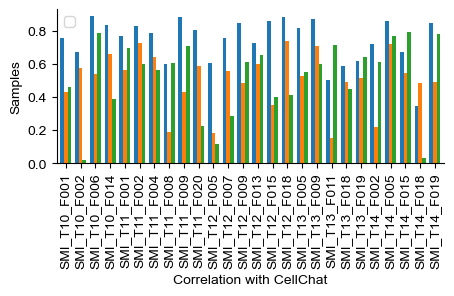

In [50]:
cellchat_corr_df[['steamboat_r', 'adjacency_r', 'cpdb_r']].plot(kind='bar', figsize=(5, 2), width=.75)
ax = plt.gca()
for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)
plt.legend('')
plt.xlabel('Correlation with CellChat')
plt.ylabel('Samples')
plt.savefig("cci-by-sample.pdf")

C:\Users\lshh\AppData\Local\Temp\ipykernel_23064\3332210529.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Steamboat', 'Adjacency', 'CellphoneDB v5'], rotation=45, va='top', ha='right', rotation_mode='anchor')


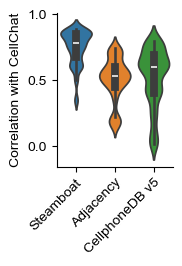

In [59]:
fig, ax = plt.subplots(figsize=(1.5, 2))
sns.violinplot(cellchat_corr_df[['steamboat_r', 'adjacency_r', 'cpdb_r']], bw_adjust=0.5, orient='v', ax=ax)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

ax.set_yticks([0, 0.5, 1])
ax.set_xticklabels(['Steamboat', 'Adjacency', 'CellphoneDB v5'], rotation=45, va='top', ha='right', rotation_mode='anchor') 
                  # rotation=45, rotation_mode='anchor', ha='right', va='center')
ax.set_ylabel('Correlation with CellChat')
fig.savefig("cci.pdf")

In [131]:
nichenet_unmelt = pd.read_csv("nichenet-res/nichenet_SMI_T10_F001.csv", index_col=0)
nichenet_melt = melt_helper(nichenet_unmelt + nichenet_unmelt.T)
nichenet_melt.columns = ['variable', 'value_nichenet']

cellchat_res_path = f"../data/Ex1_hgsc/cellchat/SMI_T10_F001.csv"
cellchat = pd.read_csv(cellchat_res_path, index_col=0)
cellchat_dict[k] = cellchat
cellchat_melt = melt_helper(cellchat + cellchat.T)
cellchat_melt.columns = ['variable', 'value_cellchat']

all_melt = pd.merge(cellchat_melt, nichenet_melt, on='variable', suffixes=['_cellchat', '_nichenet'])
corr_res = sp.stats.spearmanr(all_melt['value_cellchat'], all_melt['value_nichenet'])
corr_res

SignificanceResult(statistic=0.43056092843326876, pvalue=0.00875933949089545)